<a href="https://colab.research.google.com/github/itsluthfia/Modul-Praktikum-Deep-Learning/blob/main/M01_123450004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 1: Fondasi Jaringan Saraf, FNN, Aktivasi, dan Loss

**Nama:** Luthfia Laila Ramadhani
**NIM:** 123450004
**Kelas:** RB  
**Tanggal:** 2026-09-18

**Berkas pengumpulan:** `M01_NIM.ipynb`, `M01_NIM.pdf`, dan `M01_NIM_metrics.csv`.

> Seluruh kode, eksperimen, grafik, dan analisis merupakan pekerjaan individual. Beri atribusi pada kode yang diadaptasi dari sumber lain.

## Petunjuk

1. Ganti seluruh penanda `TODO`.
2. Jangan mengubah protokol eksperimen kecuali diminta.
3. Gunakan validation set untuk memilih model. Test set hanya untuk model final.
4. Sebelum mengumpulkan, jalankan **Restart Kernel and Run All**.
5. Pertahankan semua hasil eksperimen, termasuk hasil yang tidak sesuai hipotesis.

In [2]:
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.datasets import make_moons
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

NIM = '12340004'  # TODO: ganti dengan NIM lengkap
assert NIM.isdigit() and len(NIM) >= 4, '123450004'
NIM_LAST4 = int(NIM[-4:])
SEED = 1000 + NIM_LAST4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.13.15',
 'numpy': '2.1.3',
 'pandas': '2.2.3',
 'sklearn': '1.6.1',
 'torch': '2.11.0+cu128',
 'device': 'cuda',
 'seed': 1004}

## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum.

1. **Parameter vs hyperparameter:** Parameter merupakan nilai-nilai di dalam model yang dipelajari otomatis selama training lewat backpropagation dan Hyperparameter merupakan nilai-nilai yang ditentukan sebelum training dimulai, dan tidak diubah oleh proses training itu sendiri.
2. **Mengapa tumpukan layer affine tanpa aktivasi dapat diciutkan:** Karena layer affine berbentuk y = Wx + b (transformasi linear), jika dua layer affine ditumpuk maka hasilnya y = W2(W1x + b1) + b2. Jika diuraikan, ini bisa ditulis sebagai y = (W2W1)x + (W2b1+b2) — yang bentuknya tetap W'x + b', sama seperti satu layer affine tunggal. Karena itu, berapapun banyak layer affine yang ditumpuk tanpa aktivasi non-linear, secara matematis tetap setara dengan satu layer affine tunggal, sehingga tidak menambah kapasitas ekspresif model.
3. **Shape bobot layer 2 masukan -> 8 keluaran:** W berbentuk (8, 2) dan b berbentuk (8,), karena operasi layer adalah z = Wx + b. Dengan x berdimensi (2,) dan z (output) harus berdimensi (8,), agar perkalian matriks Wx menghasilkan vektor (8,) dari x berdimensi (2,), maka W harus berbentuk (8, 2).
4. **Mengapa `BCEWithLogitsLoss` menerima logit:** BCEWithLogitsLoss menerima logit karena secara internal ia menggabungkan operasi sigmoid dan binary cross-entropy dalam satu langkah menggunakan trik matematis (log-sum-exp) yang lebih stabil secara numerik. Jika sigmoid dihitung terpisah dulu, untuk logit yang sangat besar/kecil hasil sigmoid bisa dibulatkan jadi tepat 0 atau 1, sehingga log(0) menghasilkan -inf dan training bisa gagal (NaN). Dengan menerima logit langsung, PyTorch menghindari masalah overflow/underflow ini.

### Hipotesis awal

Prediksi aktivasi dan hidden size yang akan memberi validation loss terbaik. Jelaskan alasannya sebelum menjalankan eksperimen.

**Jawaban:** Saya menduga ReLU dengan hidden size 4 akan memberi validation loss terbaik. ReLU dipilih karena tidak mudah jenuh seperti sigmoid/tanh, sehingga gradiennya tetap besar dan training lebih cepat konvergen dengan SGD. Hidden size 4 dipilih karena pola data make_moons relatif sederhana, sehingga kapasitas neuron yang lebih besar (16) dirasa tidak diperlukan

## B. Neuron dan fungsi aktivasi dengan NumPy - 20 poin

In [4]:
def sigmoid_np(z: np.ndarray) -> np.ndarray:
    return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))

def relu_np(z: np.ndarray) -> np.ndarray:
    return np.maximum(0, z)

def leaky_relu_np(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    return np.where(z > 0, z, alpha*z)

def neuron_batch(X: np.ndarray, w: np.ndarray, b: float, activation):
    assert X.shape[1] == w.shape[0], "pesan error"
    z = X @ w + b
    a = activation(z)
    return z, a

# Uji minimum - jangan mengubah data uji.
X_check = np.array([[2.0, -1.0], [0.0, 3.0], [-2.0, 1.0]])
w_check = np.array([0.5, -0.5])
z_check, a_check = neuron_batch(X_check, w_check, 0.25, sigmoid_np)
assert z_check.shape == (3,)
assert a_check.shape == (3,)
assert np.all(np.isfinite(a_check))
assert np.all((a_check > 0) & (a_check < 1))
pd.DataFrame({'z': z_check, 'sigmoid(z)': a_check})

,z,sigmoid(z)
0,1.75,0.8520
1,-1.25,0.2227
2,-1.25,0.2227


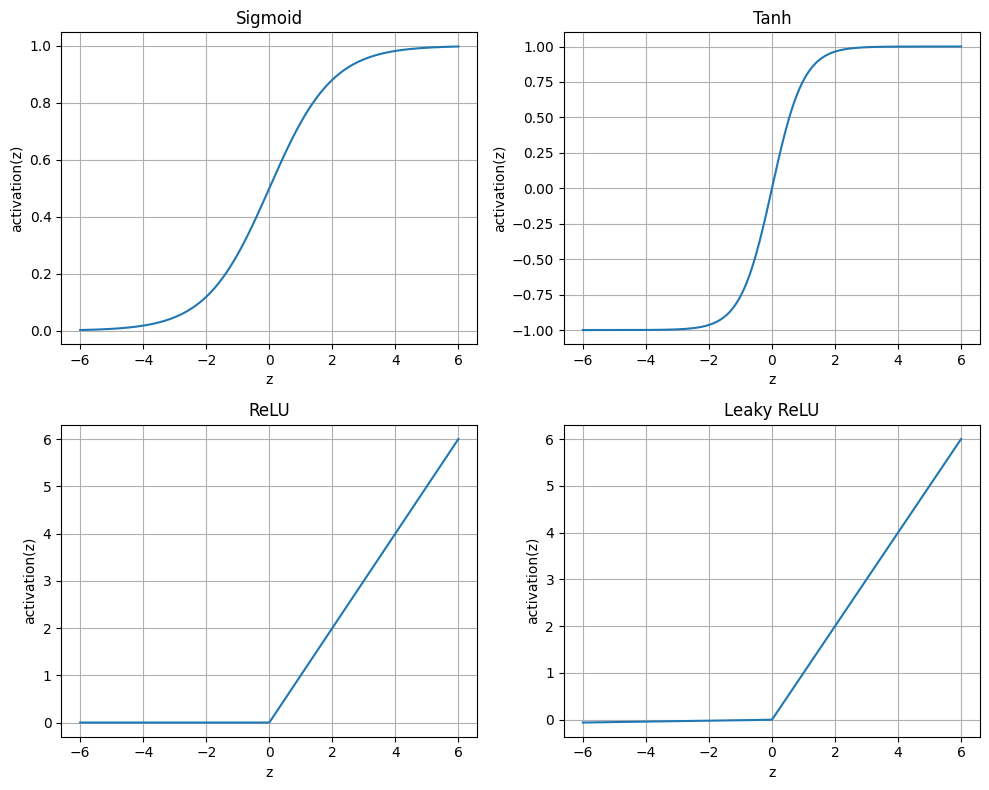

In [6]:
grid = np.linspace(-6, 6, 600)
activation_values = {
    'Sigmoid': sigmoid_np(grid),
    'Tanh': np.tanh(grid),
    'ReLU': relu_np(grid),
    'Leaky ReLU': leaky_relu_np(grid),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()  # supaya bisa di-loop 1 dimensi

for ax, (name, values) in zip(axes, activation_values.items()):
    ax.plot(grid, values)
    ax.set_title(name)
    ax.set_xlabel('z')
    ax.set_ylabel('activation(z)')
    ax.grid(True)

plt.tight_layout()
plt.show()

Interpretasi aktivasi

- **Aktivasi yang berpusat di nol:** Tanh, karena nilai outputnya berada pada rentang -1 sampai 1 dan berpusat di sekitar 0.
- **Aktivasi yang tepat nol untuk masukan negatif:** ReLU, karena untuk z<0, outputnya tepat 0.
- **Aktivasi yang mudah jenuh:** Sigmoid dan Tanh, karena pada nilai z yang sangat besar atau sangat kecil, grafik menjadi mendatar sehingga perubahan output sangat kecil.
- **Mengapa aktivasi linear tidak cukup untuk `make_moons`:** Karena aktivasi linear hanya dapat membentuk batas keputusan linear, sedangkan data make_moons memiliki pola nonlinear. Diperlukan fungsi aktivasi nonlinear seperti ReLU, Sigmoid, atau Tanh agar jaringan dapat membentuk batas keputusan yang melengkung.

## C. Forward pass manual - bagian dari 20 poin pemetaan

Gunakan arsitektur $2 \rightarrow 2 \rightarrow 1$, ReLU pada hidden layer, dan target $y=1$. Jangan mengubah bobot.

In [7]:
x_manual = np.array([[2.0, -1.0]], dtype=np.float32)
W1 = np.array([[0.5, -0.5], [1.0, 1.0]], dtype=np.float32)
b1 = np.array([0.0, 0.0], dtype=np.float32)
W2 = np.array([[2.0, -1.0]], dtype=np.float32)
b2 = np.array([0.5], dtype=np.float32)
y_manual = np.array([[1.0]], dtype=np.float32)

z1_np = np.array([[1.5, 1.0]], dtype=np.float32)
h_np = np.maximum(z1_np, 0)
logit_np = h_np @ W2.T + b2
prob_np = 1 / (1 + np.exp(-logit_np))
bce_np = -np.mean(
    y_manual * np.log(prob_np) +
    (1 - y_manual) * np.log(1 - prob_np)
)

# Jumlah parameter
parameter_count_manual = (
    W1.size + b1.size + W2.size + b2.size
)

print("z1 =", z1_np)
print("h =", h_np)
print("logit =", logit_np)
print("probabilitas =", prob_np)
print("BCE =", bce_np)
print("Jumlah parameter =", parameter_count_manual)

z1 = [[1.5 1. ]]
h = [[1.5 1. ]]
logit = [[2.5]]
probabilitas = [[0.9241418]]
BCE = 0.078889735
Jumlah parameter = 9


### Tabel shape dan nilai

| Tensor | Shape | Nilai |
|---|---:|---:|
| $x$ | (1,2) | [[2.0,−1.0]] |
| $W^{(1)}$ | (2,2) | tersedia pada kode |
| $z^{(1)}$ | (1,2) | [[1.5,1.0]] |
| $h$ | (1,2) | [[1.5,1.0]] |
| logit | (1,1) | [[2.5]] |
| probabilitas | (1,1) | [[0.9241]] |
| BCE | skalar | 0.0789 |

**Jumlah parameter dan perhitungannya:**

Jumlah parameter

= (ukuran W1) + (ukuran b1) + (ukuran W2) + (ukuran b2)

= (2×2) + 2 + (1×2) + 1

= 4 + 2 + 2 + 1

= 9

## D. Pencocokan NumPy dan PyTorch - 20 poin

Salin bobot ke `nn.Sequential`. Jangan menambahkan sigmoid ke model karena loss menerima logit.

In [9]:
manual_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
)

# Salin parameter manual ke model PyTorch
with torch.no_grad():
    manual_model[0].weight.copy_(torch.tensor(W1))
    manual_model[0].bias.copy_(torch.tensor(b1))
    manual_model[2].weight.copy_(torch.tensor(W2))
    manual_model[2].bias.copy_(torch.tensor(b2))

# Hitung output model
x_tensor = torch.tensor(x_manual)
y_tensor = torch.tensor(y_manual)
torch_logit = manual_model(x_tensor)
torch_probability = torch.sigmoid(torch_logit)
torch_loss = nn.functional.binary_cross_entropy_with_logits(
    torch_logit,
    y_tensor
)

# Pemeriksaan
assert np.max(
    np.abs(torch_logit.detach().numpy() - logit_np)
) < 1e-6

assert abs(
    torch_loss.item() - float(bce_np)
) < 1e-6

assert sum(
    p.numel() for p in manual_model.parameters()
) == parameter_count_manual

print("torch_logit =", torch_logit)
print("torch_probability =", torch_probability)
print("torch_loss =", torch_loss)
print("Jumlah parameter =", sum(p.numel() for p in manual_model.parameters()))
print("Semua pemeriksaan berhasil!")

torch_logit = tensor([[2.5000]], grad_fn=<AddmmBackward0>)
torch_probability = tensor([[0.9241]], grad_fn=<SigmoidBackward0>)
torch_loss = tensor(0.0789, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
Jumlah parameter = 9
Semua pemeriksaan berhasil!


### Checkpoint menit ke-85

Tunjukkan kepada asisten:

- plot empat fungsi aktivasi;
- tabel shape dan parameter; dan
- selisih forward NumPy-PyTorch kurang dari $10^{-6}$.

**Status/verifikasi asisten:** TODO

## E. Dataset dan protokol eksperimen

Kode split dan standardisasi diberikan agar fokus tetap pada FNN. Jangan menggunakan test set sampai model final dipilih.

,split,n,positive_rate
0,train,360,0.5
1,validation,120,0.5
2,test,120,0.5


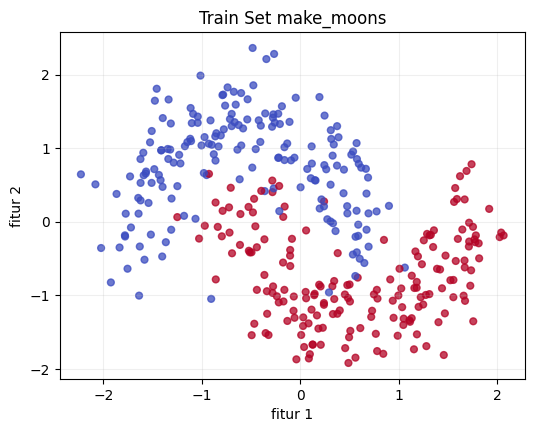

In [10]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=SEED)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)
y_val_f = y_val.astype(np.float32).reshape(-1, 1)
y_test_f = y_test.astype(np.float32).reshape(-1, 1)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n': [len(y_train), len(y_val), len(y_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap='coolwarm', s=24, alpha=0.75)
ax.set(title='Train Set make_moons', xlabel='fitur 1', ylabel='fitur 2')
ax.grid(alpha=0.2)
plt.show()

### Pemeriksaan anti-leakage

Jelaskan mengapa scaler hanya di-fit pada train set dan bukan seluruh data.

**Jawaban:** Scaler hanya di-fit pada train set agar tidak terjadi data leakage. Jika seluruh data digunakan saat fitting scaler, informasi dari validation dan test set ikut masuk ke proses preprocessing. Scaler yang sudah di-fit pada train kemudian digunakan untuk mentransformasi train, validation, dan test. Jika scaler di-fit ke seluruh data, model secara tidak langsung 'mengintip' distribusi data validation/test sebelum evaluasi, sehingga performa model pada val/test bisa terlihat lebih baik dari kondisi sebenarnya (over-optimistic) dan tidak mencerminkan kemampuan model pada data baru yang benar-benar belum pernah dilihat.

## F. Model dan utilitas training

Lengkapi pemilihan aktivasi dan model. Training loop diberikan; mekanismenya dibahas pada Modul 2.

In [11]:
def activation_layer(name: str) -> nn.Module:
    name = name.lower()
    if name == 'relu':
        return nn.ReLU()
    elif name == 'tanh':
        return nn.Tanh()
    elif name == 'sigmoid':
        return nn.Sigmoid()
    else:
        raise ValueError(f"Aktivasi tidak dikenali: {name}")


def build_model(hidden_dim: int, activation: str, seed: int = SEED):
    seed_everything(seed)

    model = nn.Sequential(
        nn.Linear(2, hidden_dim),
        activation_layer(activation),
        nn.Linear(hidden_dim, 1)
    )
    return model

def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())


# Buat model 2 -> 8 -> 1 dan cek jumlah parameter
model_check = build_model(8, 'relu')
assert count_parameters(model_check) == 33
print("Jumlah parameter:", count_parameters(model_check))

Jumlah parameter: 33


In [12]:
def as_tensor(array):
    return torch.as_tensor(array, dtype=torch.float32)

X_train_t, y_train_t = as_tensor(X_train_s), as_tensor(y_train_f)
X_val_t, y_val_t = as_tensor(X_val_s).to(DEVICE), as_tensor(y_val_f).to(DEVICE)
X_test_t, y_test_t = as_tensor(X_test_s).to(DEVICE), as_tensor(y_test_f).to(DEVICE)

def evaluate(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y_tensor).item()
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).to(torch.int64)
        accuracy = (predictions == y_tensor.to(torch.int64)).float().mean().item()
    return {
        'loss': loss,
        'accuracy': accuracy,
        'probabilities': probabilities.cpu().numpy().ravel(),
        'predictions': predictions.cpu().numpy().ravel(),
    }

def train_model(model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, generator=generator,
    )
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(X_batch)
        val_metrics = evaluate(model, X_val_t, y_val_t)
        history.append({
            'epoch': epoch,
            'train_loss': loss_sum / len(X_train_t),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
    return pd.DataFrame(history), time.perf_counter() - start

## G. Baseline dan latihan kelas

Baseline: ReLU, hidden size 8, SGD, learning rate 0.05, batch size 32, dan 200 epoch.

Latihan individual: digit terakhir NIM 0-4 memakai tanh; 5-9 memakai sigmoid. Prediksi hasil sebelum menjalankan.

**Prediksi:** Penggunaan Tanh diperkirakan dapat menghasilkan performa yang baik pada data make_moons karena Tanh merupakan fungsi aktivasi nonlinear yang berpusat di sekitar nol. Namun, hasilnya dapat berbeda dari baseline ReLU karena karakteristik kedua fungsi aktivasi tersebut berbeda.


== INDIVIDUAL ==
Aktivasi: Tanh
Train Loss: 0.2200
Train Accuracy: 0.9083
Validation Loss: 0.2498
Validation Accuracy: 0.9083
Waktu training: 7.90 detik


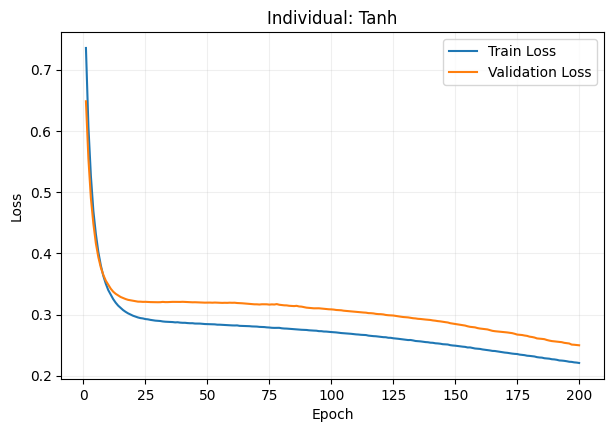

In [13]:
# Latihan individual: digit terakhir NIM = 4 → Tanh
individual_model = build_model(
    hidden_dim=8,
    activation='tanh'
).to(DEVICE)

individual_history, individual_time = train_model(
    individual_model,
    epochs=200,
    learning_rate=0.05,
    batch_size=32,
    seed=SEED
)

# Evaluasi train dan validation
individual_train_metrics = evaluate(
    individual_model,
    X_train_t.to(DEVICE),
    y_train_t.to(DEVICE)
)

individual_val_metrics = evaluate(
    individual_model,
    X_val_t,
    y_val_t
)

print("\n== INDIVIDUAL ==")
print("Aktivasi: Tanh")
print(f"Train Loss: {individual_train_metrics['loss']:.4f}")
print(f"Train Accuracy: {individual_train_metrics['accuracy']:.4f}")
print(f"Validation Loss: {individual_val_metrics['loss']:.4f}")
print(f"Validation Accuracy: {individual_val_metrics['accuracy']:.4f}")
print(f"Waktu training: {individual_time:.2f} detik")

# Plot train dan validation loss
plt.figure(figsize=(7, 4.5))
plt.plot(
    individual_history['epoch'],
    individual_history['train_loss'],
    label='Train Loss'
)
plt.plot(
    individual_history['epoch'],
    individual_history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Individual: Tanh')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## H. Tugas individual: enam eksperimen - 20 poin

Jalankan kombinasi aktivasi `{relu, tanh, sigmoid}` dan hidden size `{4, 16}`. Gunakan validation loss untuk memilih model.

In [14]:
ACTIVATIONS = ['relu', 'tanh', 'sigmoid']
HIDDEN_SIZES = [4, 16]
EPOCHS = 200
LEARNING_RATE = 0.05
BATCH_SIZE = 32

experiment_rows = []
trained_models = {}
histories = {}

for activation in ACTIVATIONS:
    for hidden_dim in HIDDEN_SIZES:

        print(f"Training: activation={activation}, hidden_dim={hidden_dim}")

        # 1. Buat model baru dengan seed yang sama
        model = build_model(
            hidden_dim=hidden_dim,
            activation=activation,
            seed=SEED
        ).to(DEVICE)

        # 2. Latih dengan konfigurasi yang sama
        history, train_time = train_model(
            model,
            epochs=EPOCHS,
            learning_rate=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            seed=SEED
        )

        # 3. Evaluasi train dan validation
        train_metrics = evaluate(
            model,
            X_train_t.to(DEVICE),
            y_train_t.to(DEVICE)
        )

        val_metrics = evaluate(
            model,
            X_val_t,
            y_val_t
        )

        # 4. Simpan model dan history
        key = f"{activation}_{hidden_dim}"
        trained_models[key] = model
        histories[key] = history

        # 5. Simpan metrik
        experiment_rows.append({
            'activation': activation,
            'hidden_dim': hidden_dim,
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'training_time': train_time
        })

# Buat tabel hasil
results = pd.DataFrame(experiment_rows).sort_values(
    'val_loss'
).reset_index(drop=True)

assert len(results) == 6

display(results)

# Simpan hasil ke CSV
results.to_csv(
    f'M01_{NIM_LAST4:04d}_metrics.csv',
    index=False
)

Training: activation=relu, hidden_dim=4
Training: activation=relu, hidden_dim=16
Training: activation=tanh, hidden_dim=4
Training: activation=tanh, hidden_dim=16
Training: activation=sigmoid, hidden_dim=4
Training: activation=sigmoid, hidden_dim=16


,activation,hidden_dim,train_loss,train_accuracy,val_loss,val_accuracy,training_time
0,relu,16,0.1889,0.9306,0.2092,0.9250,3.3002
1,tanh,16,0.2127,0.9083,0.2453,0.9083,3.7100
2,relu,4,0.2478,0.8889,0.3060,0.8917,5.4459
3,sigmoid,16,0.2836,0.8611,0.3228,0.8583,3.3199
4,sigmoid,4,0.2946,0.8639,0.3261,0.8583,3.3788
5,tanh,4,0.2848,0.8639,0.3264,0.8583,3.3450


## I. Evaluasi model final - 15 poin

Pilih satu model dengan validation loss terendah. Baru setelah itu evaluasi test set satu kali.

In [16]:
def plot_decision_boundary(model, X_values, y_values, title):
    model.eval()

    # Tentukan batas area plot
    x_min, x_max = X_values[:, 0].min() - 0.5, X_values[:, 0].max() + 0.5
    y_min, y_max = X_values[:, 1].min() - 0.5, X_values[:, 1].max() + 0.5

    # Buat mesh
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Ubah mesh menjadi pasangan koordinat
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.as_tensor(
        grid, dtype=torch.float32
    ).to(DEVICE)

    # Prediksi probabilitas
    with torch.no_grad():
        logits = model(grid_tensor)
        probabilities = torch.sigmoid(logits)
        probabilities = probabilities.cpu().numpy().reshape(xx.shape)

    # Plot probabilitas
    plt.figure(figsize=(7, 5))
    plt.contourf(
        xx, yy, probabilities,
        levels=np.linspace(0, 1, 21),
        alpha=0.5
    )

    # Batas keputusan probabilitas = 0.5
    plt.contour(
        xx, yy, probabilities,
        levels=[0.5],
        linewidths=2
    )

    # Scatter data
    plt.scatter(
        X_values[:, 0],
        X_values[:, 1],
        c=y_values,
        cmap='coolwarm',
        edgecolors='k',
        s=30,
        alpha=0.8
    )

    plt.xlabel('fitur 1')
    plt.ylabel('fitur 2')
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()

# Ambil run/model dengan validation loss terendah
best_row = results.iloc[0]

best_activation = best_row['activation']
best_hidden_dim = int(best_row['hidden_dim'])

run_id = f"{best_activation}_{best_hidden_dim}"

final_model = trained_models[run_id]

print("=== MODEL FINAL ===")
print(f"Aktivasi    : {best_activation}")
print(f"Hidden size : {best_hidden_dim}")
print(f"Train loss  : {best_row['train_loss']:.4f}")
print(f"Train acc   : {best_row['train_accuracy']:.4f}")
print(f"Val loss    : {best_row['val_loss']:.4f}")
print(f"Val acc     : {best_row['val_accuracy']:.4f}")

=== MODEL FINAL ===
Aktivasi    : relu
Hidden size : 16
Train loss  : 0.1889
Train acc   : 0.9306
Val loss    : 0.2092
Val acc     : 0.9250


In [18]:
# Evaluasi test set satu kali setelah model final dipilih
test_metrics = evaluate(
    final_model,
    X_test_t,
    y_test_t
)

print("=== TEST SET ===")
print(f"Test Loss     : {test_metrics['loss']:.4f}")
print(f"Test Accuracy : {test_metrics['accuracy']:.4f}")

=== TEST SET ===
Test Loss     : 0.2234
Test Accuracy : 0.9083


Confusion Matrix:
[[54  6]
 [ 5 55]]


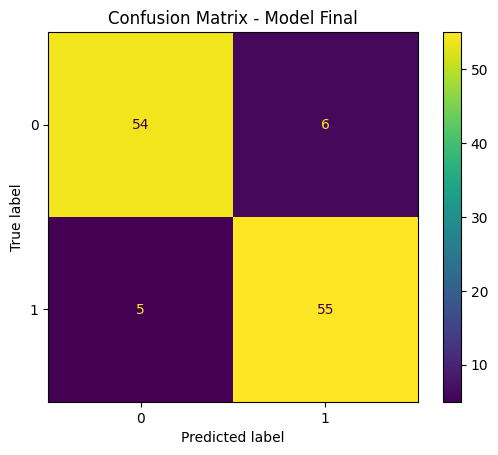

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_f.ravel(),
    test_metrics['predictions']
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix - Model Final')
plt.show()

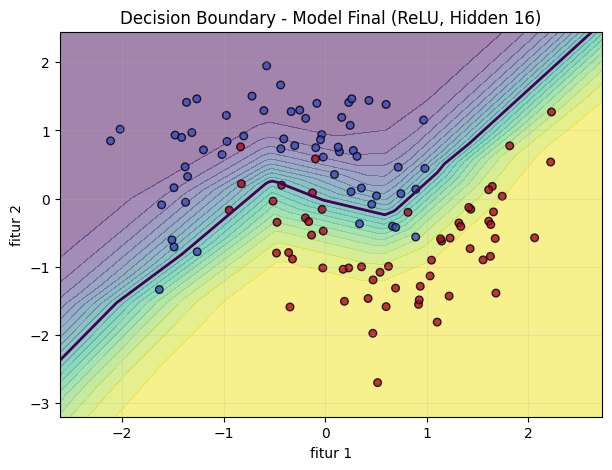

In [20]:
plot_decision_boundary(
    final_model,
    X_test_s,
    y_test_f.ravel(),
    'Decision Boundary - Model Final (ReLU, Hidden 16)'
)

## J. Analisis dan refleksi - 10 poin

Jawab dengan merujuk angka atau grafik.

1. Apakah hidden size lebih besar selalu memperbaiki validation loss? **Tidak selalu. Pada eksperimen ini hidden size 16 memang menghasilkan validation loss lebih rendah untuk semua aktivasi, tetapi besar penurunannya berbeda.**
2. Aktivasi mana yang paling stabil pada dua hidden size? **Sigmoid, karena validation loss dan accuracy paling sedikit berubah antara hidden size 4 dan 16.**
3. Adakah konfigurasi dengan accuracy serupa tetapi BCE berbeda? Mengapa? **Ada. Sigmoid-4 dan Sigmoid-16 sama-sama memiliki accuracy 0,8583, tetapi BCE berbeda karena BCE mempertimbangkan tingkat keyakinan prediksi.**
4. Di bagian mana decision boundary paling tidak pasti? **Di sekitar batas probabilitas 0,5, karena model paling tidak yakin dalam membedakan kedua kelas.**
5. Apa satu keterbatasan eksperimen ini? **Eksperimen hanya menggunakan satu seed dan kombinasi hyperparameter yang terbatas.**
6. Apakah hasil sesuai hipotesis awal? **Sebagian sesuai. Tanh cukup baik, tetapi ReLU hidden 16 menghasilkan validation loss terendah (0,2092).**

## Checklist pengumpulan - 5 poin reproduksibilitas

- [ ] Identitas, seed, versi library, dan device tercantum.
- [ ] Forward NumPy-PyTorch memiliki selisih kurang dari $10^{-6}$.
- [ ] Enam eksperimen tercatat pada notebook dan CSV.
- [ ] Test set hanya dipakai untuk model final.
- [ ] Semua grafik memiliki judul, label sumbu, dan legenda/caption.
- [ ] Notebook lolos Restart Kernel and Run All.
- [ ] Tidak ada path absolut atau data pribadi.
- [ ] Sumber eksternal telah diberi atribusi.

### Pernyataan orisinalitas

Saya menyatakan bahwa kode, eksperimen, visualisasi, dan analisis pada notebook ini merupakan pekerjaan individual saya.

**Nama dan tanggal:** TODO